# 01 Exploracion de datos

Este notebook sigue la logica de `exploration.ipynb` del repo de referencia: primero se cargan los datos crudos, luego se inspeccionan columnas, tipos, rangos, distribuciones y patrones visuales.

En este notebook se revisan:

- hojas disponibles,
- columnas principales,
- rangos de fechas,
- cantidad de productos,
- posibles duplicados por diferencias de signos, espacios o tildes.
- comportamiento historico por mes para PT y PP.

In [1]:
from pathlib import Path
import sys
from io import StringIO

import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import Markdown, display

def find_project_root(start=None):
    current = Path(start or Path.cwd()).resolve()
    for candidate in [current, *current.parents]:
        if (candidate / "config" / "config.yml").exists() and (candidate / "src").exists():
            return candidate
    raise FileNotFoundError("No se encontro la raiz del proyecto. Abre VS Code en la carpeta 'Avance 3'.")

ROOT = find_project_root()
sys.path.insert(0, str(ROOT / "src"))

pd.set_option("display.max_columns", 80)
pd.set_option("display.max_rows", 30)
plt.style.use("default")

from quickbooks_forecast.config import load_config

config = load_config()
reports_dir = config["resolved_paths"]["reports_dir"]
processed_dir = config["resolved_paths"]["processed_dir"]
raw_dir = config["resolved_paths"]["raw_dir"]
images_dir = ROOT / "notebooks" / "images"
images_dir.mkdir(parents=True, exist_ok=True)

def save_fig(name, extension="png", resolution=160):
    path_final = images_dir / f"{name}.{extension}"
    plt.tight_layout()
    plt.savefig(path_final, dpi=resolution, bbox_inches="tight")
    print(f"Figura guardada: {path_final}")

In [2]:
files = {
    "catalogo": config["resolved_paths"]["catalog"],
    "ventas": config["resolved_paths"]["sales"],
    "produccion": config["resolved_paths"]["production"],
}

for name, path in files.items():
    xl = pd.ExcelFile(path)
    print(name, "->", path.name)
    print("hojas:", xl.sheet_names)
    print()

catalogo -> ean 13 ean 14 pvp.xlsx
hojas: ['QuickBooks Desktop Export Tips', 'Hoja1']

ventas -> Ventas Econespecias.xlsx
hojas: ['Hoja1', 'datos ventas 2023 - actualidad']

produccion -> PRODUCCION2025.xlsx
hojas: ['Hoja1', 'Categorías']



**Validacion de fuentes de datos:**

Aqui se confirma que existen las fuentes de datos principales: catalogo EAN, ventas QuickBooks y produccion. Esta validacion inicial evita entrenar el modelo con archivos incorrectos.

In [3]:
catalogo_raw = pd.read_excel(
    config["resolved_paths"]["catalog"],
    sheet_name=config["sheets"]["catalog"],
)
ventas_raw = pd.read_excel(
    config["resolved_paths"]["sales"],
    sheet_name=config["sheets"]["sales"],
)
produccion_raw = pd.read_excel(
    config["resolved_paths"]["production"],
    sheet_name=config["sheets"]["production"],
)

print("catalogo:", catalogo_raw.shape)
print("ventas:", ventas_raw.shape)
print("produccion:", produccion_raw.shape)

catalogo: (2707, 9)
ventas: (25796, 8)
produccion: (30724, 8)


**Carga y dimensiones de datos:**

Las dimensiones permiten verificar el volumen disponible para modelar. PT tiene historico de ventas y PP toma su historico desde produccion.

In [4]:
print("Primeras filas del catalogo")
display(catalogo_raw.head())
print("Primeras filas de ventas")
display(ventas_raw.head())
print("Primeras filas de produccion")
display(produccion_raw.head())

Primeras filas del catalogo


,Unnamed: 0,Unnamed: 1,Item,Unnamed: 3,Description,U/M,Price,EAN13,EAN14
0,NaN,NaN,303A,NaN,NaN,NaN,0.0,NaN,NaN
1,NaN,NaN,303A:ServiciosProfesionales Soc Adm,NaN,Servicios Profesionales Sociedades Adm,NaN,0.0,NaN,NaN
2,NaN,NaN,303A:ServiciosProfesionales Soc Prod,NaN,Servicios Profesionales Sociedades Prod,NaN,0.0,NaN,NaN
3,NaN,NaN,304,NaN,NaN,NaN,0.0,NaN,NaN
4,NaN,NaN,304:Mant. Eq. Comp y Software,NaN,NaN,NaN,0.0,NaN,NaN


Primeras filas de ventas


,Marca,Familia,Producto,Recuento de Cliente,Cantidad,Ventas,Año,Mes
0,1 CONDIMENSA,CONDIMENTOS EN PASTAS,* ALINO FDA 90 GRS (4488),8,195798,26659.56,2023,mayo
1,1 CONDIMENSA,CONDIMENTOS EN PASTAS,* ALINO FDA 90 GRS (4488),12,169902,23323.82,2023,enero
2,1 CONDIMENSA,CONDIMENTOS EN PASTAS,* ALINO FDA 90 GRS (4488),11,128684,16752.44,2023,diciembre
3,MAQUILA,MAQUILA SUPERMAXI,EL ARTESANAL ACEITE VEGETAL 1L (3058),1,127707,178789.80,2025,septiembre
4,MAQUILA,MAQUILA SUPERMAXI,EL ARTESANAL ACEITE GIRASOL 1L (4841),1,113711,196720.03,2025,diciembre


Primeras filas de produccion


,No.,FECHA,NUMERO,LOTE,PRODUCTO,Q. PANIFICDA,Q. LIBERADA,Q. FABRICADA
0,1,2024-06-28 00:00:00,240628-55,180AL55,PT:1 CONDIMENSA:CONDIMENTOS EN POLVO:COMINO MO...,2240.000,2242.00,2242.00
1,2,2024-06-28 00:00:00,240628-56,180AA-56,PP:SALSA TOMATE PRODUCCION GRANEL,695.525,647.25,647.25
2,3,2024-06-29 00:00:00,240629-20,180VC55,PP SMART SELECTION:SM.SELECTION AJO FUNDA 300G,480.000,480.00,480.00
3,4,2024-06-29 00:00:00,240629-21,181SK21,PT:MAQUILA:MAQUILA SUPERMAXI:SMART SELECTION:S...,240.000,240.00,240.00
4,5,2024-06-29 00:00:00,240629-22,181VC22,PP SMART SELECTION:SM.SELECTION CEBOLL FUNDA 300G,600.000,600.00,600.00


**Revision inicial de estructuras:**

La inspeccion visual de primeras filas permite validar nombres de columnas, formatos y si las variables corresponden al proceso de negocio esperado.

In [5]:
buffer = StringIO()
ventas_raw.info(buf=buffer)
print("INFO ventas")
print(buffer.getvalue())

buffer = StringIO()
produccion_raw.info(buf=buffer)
print("INFO produccion")
print(buffer.getvalue())

INFO ventas
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25796 entries, 0 to 25795
Data columns (total 8 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Marca                25796 non-null  object 
 1   Familia              25796 non-null  object 
 2   Producto             25796 non-null  object 
 3   Recuento de Cliente  25796 non-null  int64  
 4   Cantidad             25796 non-null  int64  
 5   Ventas               25796 non-null  float64
 6   Año                  25796 non-null  int64  
 7   Mes                  25796 non-null  object 
dtypes: float64(1), int64(3), object(4)
memory usage: 1.6+ MB

INFO produccion
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30724 entries, 0 to 30723
Data columns (total 8 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   No.           30724 non-null  int64  
 1   FECHA         30724 non-null  object 
 2   NUMERO        30

**Diagnostico de tipos y ausencias:**

Los tipos de datos y valores ausentes guian la limpieza posterior: fechas, cantidades numericas y nombres de productos deben quedar estandarizados antes del entrenamiento.

In [6]:
ventas_periodo = ventas_raw.copy()
ventas_periodo["Año"] = pd.to_numeric(ventas_periodo["Año"], errors="coerce")

produccion_fecha = pd.to_datetime(produccion_raw["FECHA"], errors="coerce")

print("Años ventas:", sorted(ventas_periodo["Año"].dropna().astype(int).unique()))
print("Fecha minima produccion:", produccion_fecha.min())
print("Fecha maxima produccion:", produccion_fecha.max())
print("Productos unicos en ventas:", ventas_raw["Producto"].nunique())
print("Productos unicos en produccion:", produccion_raw["PRODUCTO"].nunique())

Años ventas: [np.int64(2023), np.int64(2024), np.int64(2025), np.int64(2026)]
Fecha minima produccion: 2024-06-28 00:00:00
Fecha maxima produccion: 2026-02-28 00:00:00
Productos unicos en ventas: 1244
Productos unicos en produccion: 1073


**Cobertura temporal y volumen de productos:**

Este bloque justifica el horizonte historico: PT se entrena con ventas desde 2023 y PP con produccion desde 2024. Tambien muestra la escala de productos que debe manejar el modelo.

In [7]:
display(ventas_raw.describe(include="all").transpose())
display(produccion_raw.describe(include="all").transpose())

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Marca,25796,3,1 CONDIMENSA,13929,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Familia,25796,64,MAQUILA SUPERMAXI,6518,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Producto,25796,1244,* ALINO FDA 90 GRS (4488),39,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Recuento de Cliente,25796.0,NaN,NaN,NaN,6.117383,7.551245,1.0,1.0,3.0,9.0,71.0
Cantidad,25796.0,NaN,NaN,NaN,3195.855404,6564.213712,-5679.0,259.75,1209.0,3287.25,195798.0
Ventas,25796.0,NaN,NaN,NaN,2539.058148,6055.495191,-6307.32,347.1825,1106.275,2646.7525,196720.03
Año,25796.0,NaN,NaN,NaN,2024.205381,0.955207,2023.0,2023.0,2024.0,2025.0,2026.0
Mes,25796,12,marzo,2679,NaN,NaN,NaN,NaN,NaN,NaN,NaN


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
No.,30724.0,NaN,NaN,NaN,7279.220902,5596.96639,1.0,2395.0,6235.5,11571.25,19252.0
FECHA,30724,501,2025-05-01 00:00:00,114,NaN,NaN,NaN,NaN,NaN,NaN,NaN
NUMERO,30724,30646,260209-26,3,NaN,NaN,NaN,NaN,NaN,NaN,NaN
LOTE,30724,30143,282AL-10,7,NaN,NaN,NaN,NaN,NaN,NaN,NaN
PRODUCTO,30724,1073,PT:1 CONDIMENSA:ACEITES Y GRASAS:ACHIOTE EN PA...,294,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Q. PANIFICDA,30724.0,NaN,NaN,NaN,2637.702122,4732.729667,0.0,373.46,904.9,2700.0,61440.0
Q. LIBERADA,29439.0,NaN,NaN,NaN,2617.51571,4536.760358,0.0,400.0,960.0,2750.0,61440.0
Q. FABRICADA,29427.0,NaN,NaN,NaN,2617.74334,4537.307484,0.0,400.0,960.0,2750.0,61440.0


**Estadisticos de control:**

El resumen estadistico ayuda a detectar cantidades extremas, columnas con muchos nulos y posibles inconsistencias antes de construir el dataset mensual.

In [8]:
from quickbooks_forecast.cleaning import normalize_product_name

def duplicate_groups(df, column):
    tmp = df[[column]].dropna().copy()
    tmp["producto_norm"] = tmp[column].map(normalize_product_name)
    groups = (
        tmp.groupby("producto_norm")[column]
        .agg(lambda values: sorted(set(map(str, values))))
        .reset_index()
    )
    groups["variantes"] = groups[column].map(len)
    return groups[groups["variantes"].gt(1)].sort_values("variantes", ascending=False)

dup_ventas = duplicate_groups(ventas_raw, "Producto")
dup_produccion = duplicate_groups(produccion_raw, "PRODUCTO")

print("Grupos duplicados ventas:", dup_ventas.shape[0])
display(dup_ventas.head(10))
print("Grupos duplicados produccion:", dup_produccion.shape[0])
display(dup_produccion.head(10))

Grupos duplicados ventas: 38


,producto_norm,Producto,variantes
97,AKI ALPISTE 500G 5426,"[ AKI ALPISTE 500G (5426), * AKI ALPISTE 500G ...",3
128,ALINO COMPLETO DISPLAY X 15 0 10 1111,"[* ALIÑO COMPLETO DISPLAY X 15 (0.10)(1111), ...",3
702,LA ORIGINAL CHIMICHURRI BOTELLA 500 GR 8987,[*LA ORIGINAL CHIMICHURRI BOTELLA 500 GR (8987...,3
904,PICAJIN FRASCO 75G 5965,"[* PICAJIN FRASCO 75G (5965), *PICAJIN FRASCO ...",3
606,GRANOLA CON FRUTOS SECOS FUNDA 280G 0821,"[* GRANOLA CON FRUTOS SECOS FUNDA 280G (0821),...",3
607,GRANOLA FUNDA 135G 0814,"[*GRANOLA FUNDA 135G(0814), GRANOLA FUNDA 135G...",3
251,BOLITAS DE TAMARINDO TARRINA 85G 1156,"[*BOLITAS DE TAMARINDO TARRINA 85G (1156), BOL...",2
203,ANIS ESTRELL DISPLAY X15 0 15 8189,"[ANIS ESTRELL DISPLAY X15 ($0.15)(8189), ANIS ...",2
124,ALINO BOT 310 GRS 8608,"[ * ALINO BOT 310 GRS. (8608), * ALINO BOT 31...",2
115,ALBAHACA DISP X 10 0 25 1899,"[ALBAHACA DISP X 10 $0.25 (1899), ALBAHACA DIS...",2


Grupos duplicados produccion: 70


,producto_norm,PRODUCTO,variantes
16,PP AENG ANIS ESTRELL DISP X 30,"[PP:AENG ANIS ESTRELL DISP X 30, PP:AENG ANIS...",2
25,PP AENG POLVO HORNEAR DISP X 30,"[PP:AENG POLVO HORNEAR DISP X 30.., PP:AENG P...",2
117,PP ENG OREGANO DISPLA Y X10 0 25,"[PP:ENG OREGANO DISPLA Y X10 (0.25, PP:ENG OR...",2
169,PP PAPRIKA PRODUCCION GRANEL,"[PP:PAPRIKA PRODUCCION GRANEL, PP:PAPRIKA PRO...",2
208,PP SAZONADOR CARNES ROJAS KL GR,"[PP:* SAZONADOR CARNES ROJAS KL GR, PP:* SAZO...",2
210,PP SAZONADOR CERDO LIBRAS GRANE,"[PP:* SAZONADOR CERDO LIBRAS GRANE, PP:* SAZO...",2
217,PP SMART SELECTION SM SELECTION AJO FUNDA 300G,[PP SMART SELECTION:SM.SELECTION AJO FUNDA 30...,2
218,PP SMART SELECTION SM SELECTION CANELA FUNDA 100G,[PP SMART SELECTION:SM.SELECTION CANELA FUNDA ...,2
219,PP SMART SELECTION SM SELECTION CEBOLL FUNDA 300G,[PP SMART SELECTION:SM.SELECTION CEBOLL FUNDA ...,2
220,PP SMART SELECTION SM SELECTION COM M FUNDA 300G,"[PP SMART SELECTION:SM.SELECTION COM, M FUNDA ...",2


**Deteccion de duplicados por nombre:**

Esta revision responde al problema de nombres parecidos: signos, tildes y espacios pueden separar productos que realmente son iguales. La normalizacion reduce duplicados artificiales.

In [9]:
ventas_top = (
    ventas_raw.groupby("Producto", dropna=False)["Cantidad"]
    .sum()
    .sort_values(ascending=False)
    .head(20)
    .reset_index()
)
display(ventas_top)

prod_top = (
    produccion_raw.groupby("PRODUCTO", dropna=False)["Q. FABRICADA"]
    .sum()
    .sort_values(ascending=False)
    .head(20)
    .reset_index()
)
display(prod_top)

,Producto,Cantidad
0,* ALINO FDA 90 GRS (4488),2146788
1,* ALINO BOT 310 GRS. (8608),1680673
2,CANELA RAMA FDA 30 GRS(0077),1622275
3,* SAZON COMPLETA BOT 310 G (8615),1439744
4,* ALINO FDA 200 GRS. (9060),1315405
5,ACHIOTE ACEITE BOT 190C REDONDA(4135),1177419
6,PAPRIKA FCO 40G (1127),960003
7,COMINO MOLIDO FDA 50 GRS. (1616),952254
8,* ALINO FDA 400 GRS. (9053),943741
9,MANI PASTA TARRINA 140G(6634),940181


,PRODUCTO,Q. FABRICADA
0,PP:ENG ACHIOTE PASTA DP X 30(0.10),3627795.0
1,PP:* ALINO COMPLETO KILOS GRANEL,2314769.0
2,PP:ENG ALIÑO DP X 30 (0.10),1817685.0
3,PP:ENG BICARBONATO X 30 (0.15),1681570.0
4,PP:CEBOLLA PAITEÑA PELADA,1345631.0
5,PP:ENG CANELA RAMA DISP X 15 (0.20,1170410.0
6,PT:1 CONDIMENSA:CONDIMENTOS EN PASTAS:ALIÑO CO...,1064014.0
7,PT:1 CONDIMENSA:CONDIMENTOS EN PASTAS:ALIÑO CO...,999061.0
8,PT:1 CONDIMENSA:ESPECIAS Y DESHIDRATADOS:CANEL...,992399.0
9,PP:* SAZON COMPLETA KILOS GRANEL,951455.5


**Productos de mayor impacto:**

Los productos de mayor volumen tienen mas impacto en el WAPE total. Por eso se revisan aparte y luego aparecen como prioridad en la evaluacion operativa.

Figura guardada: F:\proyecto-integrador\Avance 3\Modelado\forecasting_v3\notebooks\images\01_series_mensuales_pt_pp.png


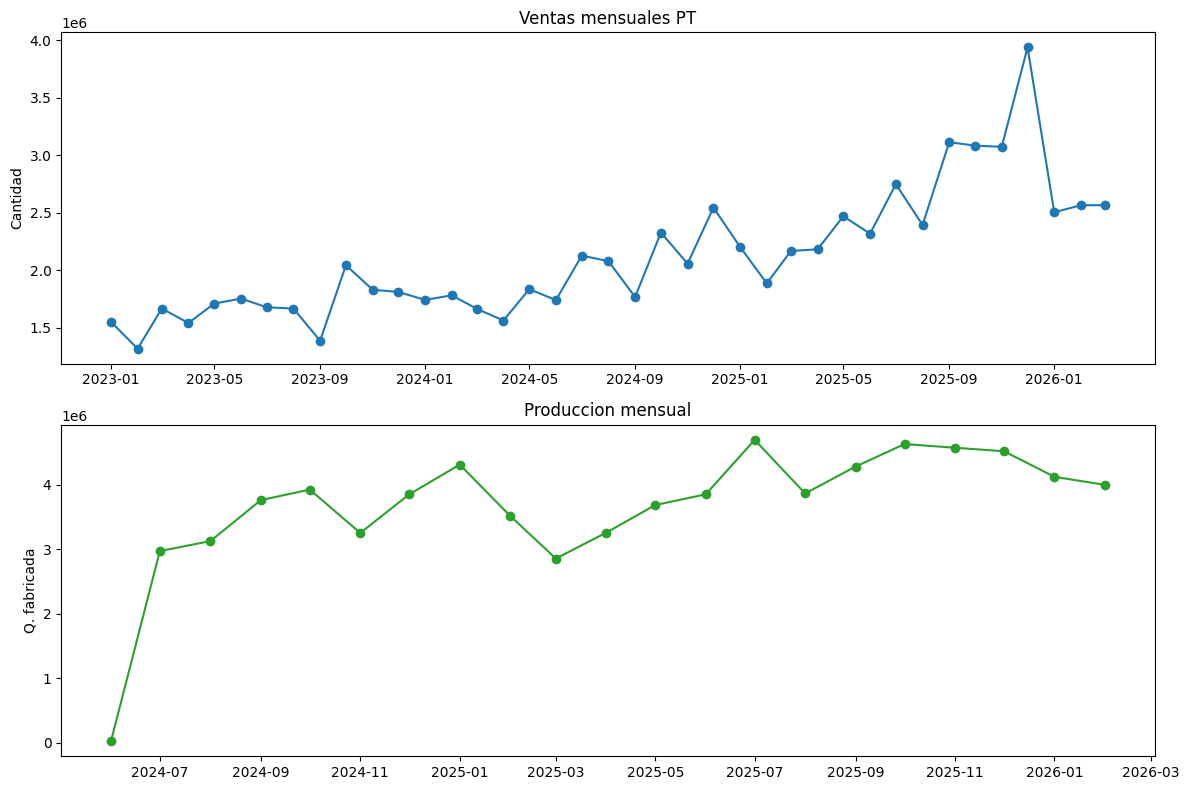

In [10]:
from quickbooks_forecast.cleaning import to_month_start

ventas_plot = ventas_raw.copy()
ventas_plot["periodo"] = to_month_start(ventas_plot["Año"], ventas_plot["Mes"])
ventas_mensual = ventas_plot.groupby("periodo", as_index=False)["Cantidad"].sum()

produccion_plot = produccion_raw.copy()
produccion_plot["FECHA"] = pd.to_datetime(produccion_plot["FECHA"], errors="coerce")
produccion_plot["periodo"] = produccion_plot["FECHA"].values.astype("datetime64[M]")
produccion_mensual = produccion_plot.groupby("periodo", as_index=False)["Q. FABRICADA"].sum()

fig, axes = plt.subplots(2, 1, figsize=(12, 8), sharex=False)
axes[0].plot(ventas_mensual["periodo"], ventas_mensual["Cantidad"], marker="o")
axes[0].set_title("Ventas mensuales PT")
axes[0].set_ylabel("Cantidad")
axes[1].plot(produccion_mensual["periodo"], produccion_mensual["Q. FABRICADA"], marker="o", color="tab:green")
axes[1].set_title("Produccion mensual")
axes[1].set_ylabel("Q. fabricada")
save_fig("01_series_mensuales_pt_pp")
plt.show()

**Series mensuales historicas:**

La serie mensual permite identificar tendencia, meses altos y cambios bruscos. Estos patrones explican por que se agregaron variables de calendario y temporada.

Figura guardada: F:\proyecto-integrador\Avance 3\Modelado\forecasting_v3\notebooks\images\01_distribucion_cantidades_ventas.png


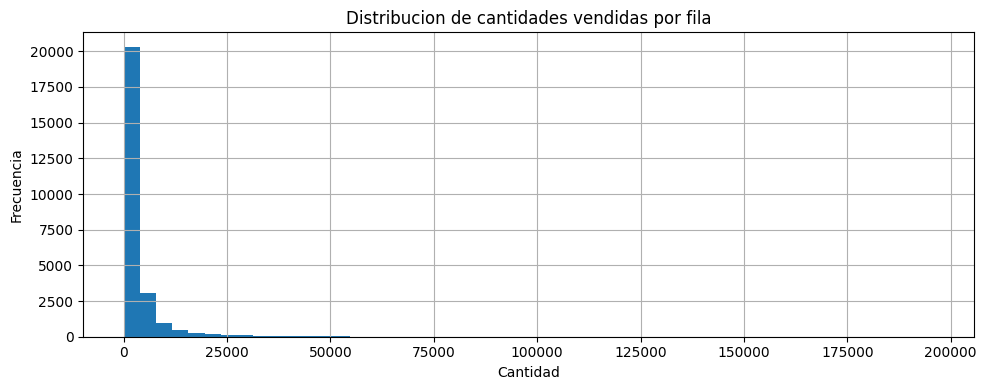

In [11]:
ventas_raw["Cantidad"].clip(lower=0).hist(bins=50, figsize=(10, 4))
plt.title("Distribucion de cantidades vendidas por fila")
plt.xlabel("Cantidad")
plt.ylabel("Frecuencia")
save_fig("01_distribucion_cantidades_ventas")
plt.show()

**Distribucion de cantidades:**

La distribucion muestra que hay muchos movimientos pequenos y pocos movimientos grandes. Por eso se usa WAPE, porque pondera el error por volumen y no trata igual un error pequeno y uno de alto impacto.